   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

--- Initial Model ---
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Fitting 5 folds f

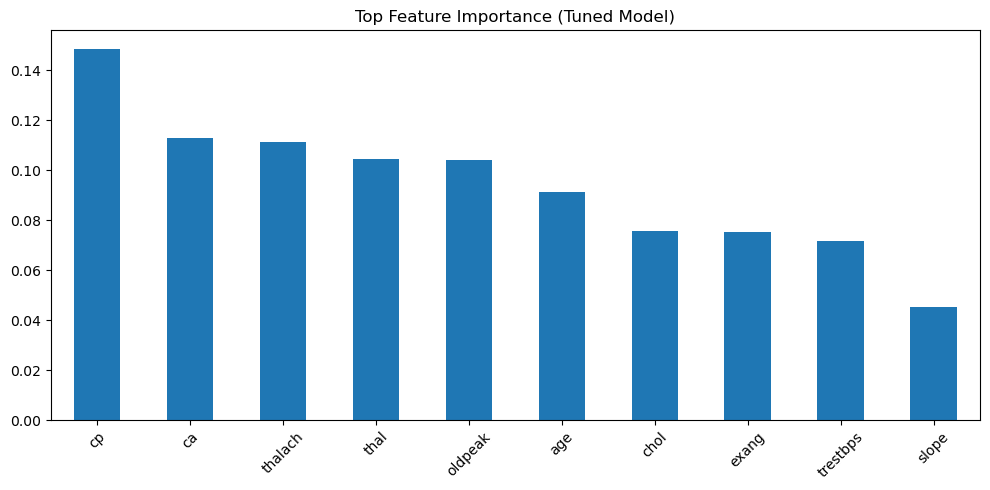

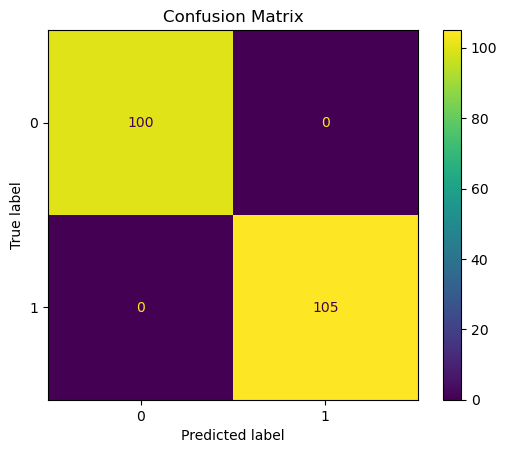

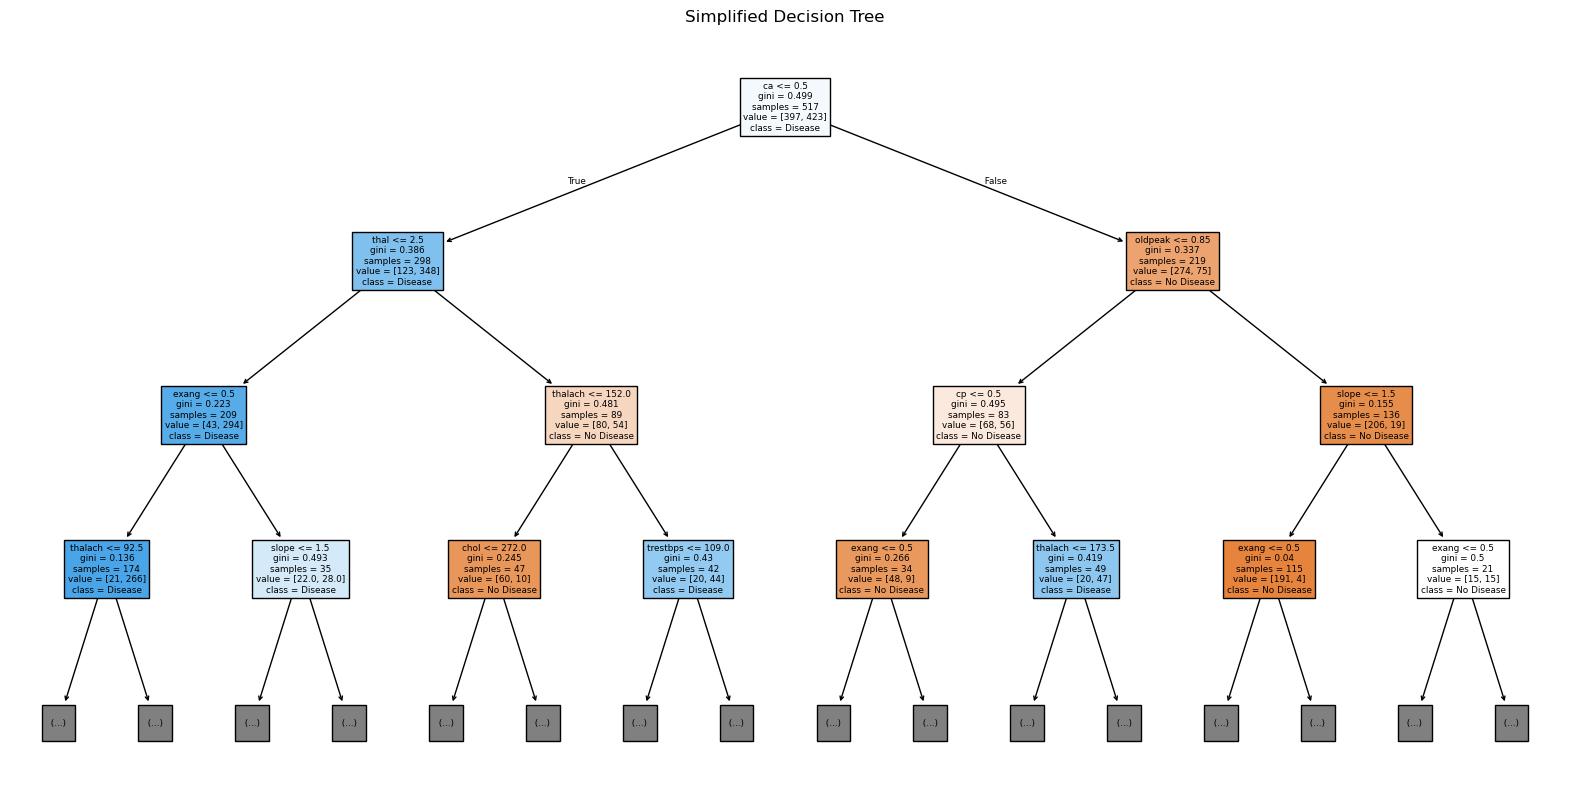

|--- ca <= 0.50
|   |--- thal <= 2.50
|   |   |--- exang <= 0.50
|   |   |   |--- thalach <= 92.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- thalach >  92.50
|   |   |   |   |--- thalach <= 169.50
|   |   |   |   |   |--- thalach <= 168.50
|   |   |   |   |   |   |--- chol <= 283.50
|   |   |   |   |   |   |   |--- trestbps <= 109.00
|   |   |   |   |   |   |   |   |--- chol <= 245.50
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- chol >  245.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- trestbps >  109.00
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- chol >  283.50
|   |   |   |   |   |   |   |--- sex <= 0.50
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- sex >  0.50
|   |   |   |   |   |   |   |   |--- thalach <= 161.00
|   |   |   |   |   |   |   |   |   |--- thalach <= 154.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("C:/Users/LENOVO/Downloads/heart.csv")

print(df.head())

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\n--- Initial Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\n--- Best Parameters ---")
print(grid_search.best_params_)

y_pred_best = best_model.predict(X_test)

print("\n--- Tuned Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


import matplotlib.pyplot as plt

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importances.head(10).plot(kind='bar')

plt.title("Top Feature Importance (Tuned Model)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

tree = best_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3
)
plt.title("Simplified Decision Tree")
plt.show()

rules = export_text(tree, feature_names=list(X_train.columns))
print(rules)